In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('data/VN_House_price_Clean2.csv')

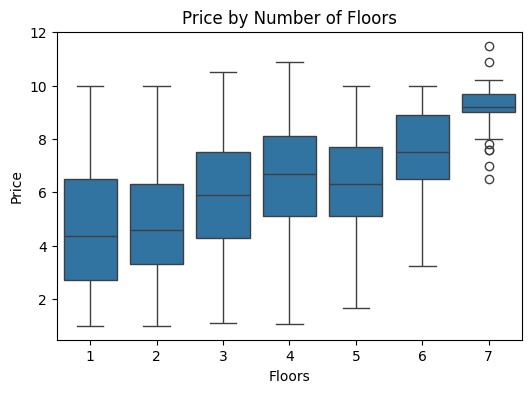

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Floors",
    y="Price",
    data=df
)
plt.title("Price by Number of Floors")
plt.show()


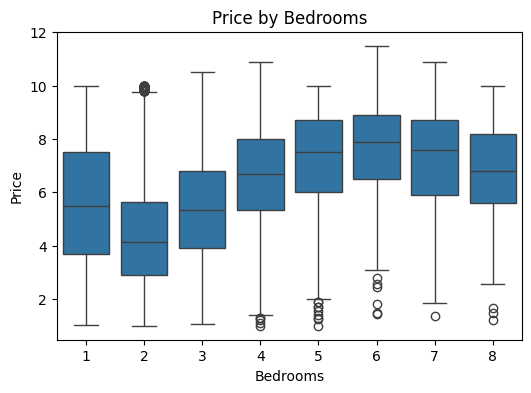

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Bedrooms",
    y="Price",
    data=df
)
plt.title("Price by Bedrooms")
plt.show()


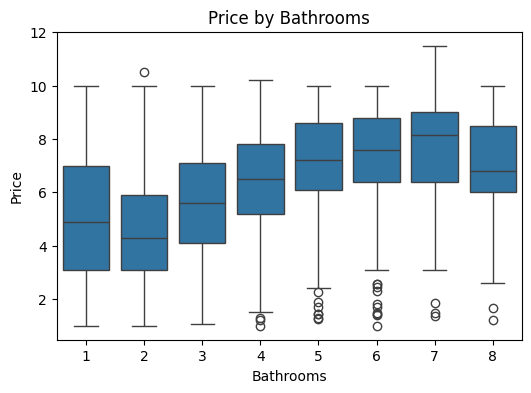

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Bathrooms",
    y="Price",
    data=df
)
plt.title("Price by Bathrooms")
plt.show()


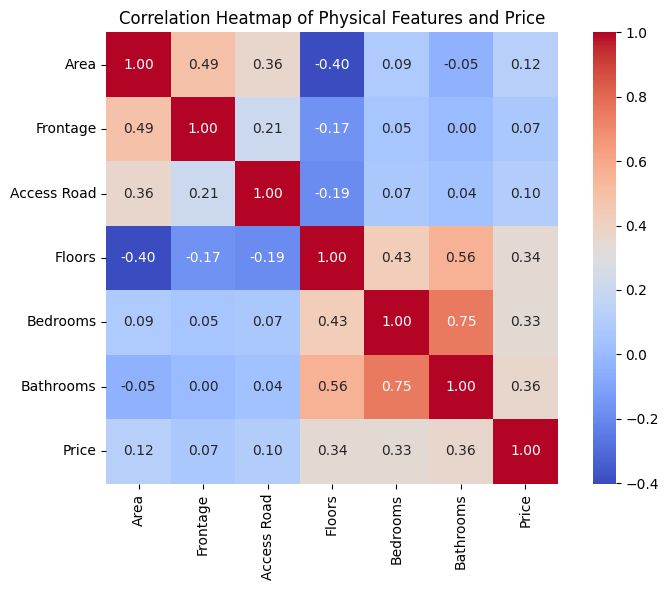

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chỉ lấy các cột số
num_cols = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Price"
]

# Tính ma trận tương quan
corr = df[num_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap of Physical Features and Price")
plt.tight_layout()
plt.show()


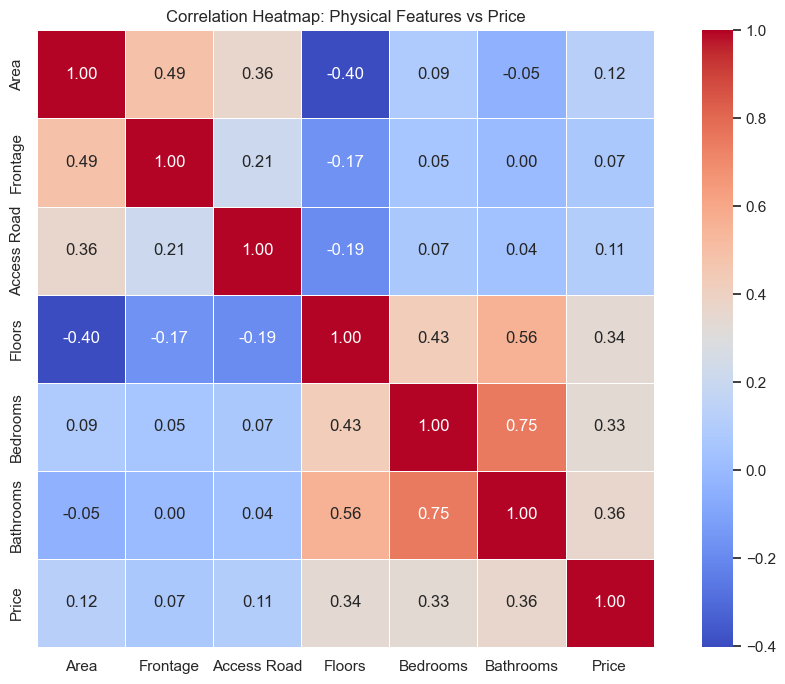

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("VN_House_price_Clean2.csv")

# Chọn các cột vật lý + Price
num_cols = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms", "Price"]

# Ma trận tương quan
corr = df[num_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Physical Features vs Price")
plt.tight_layout()
plt.show()


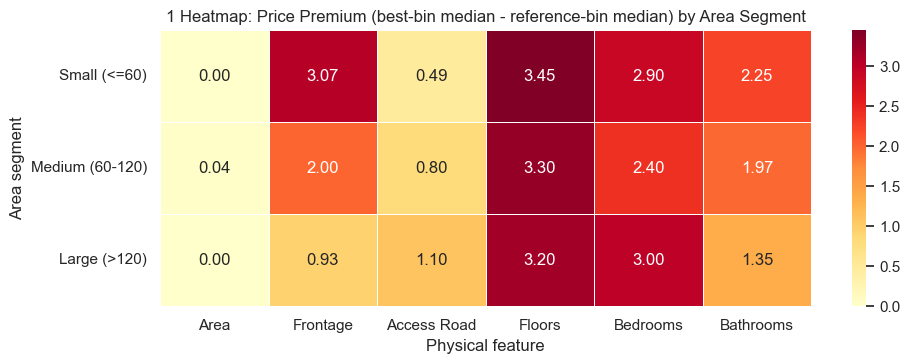

Reference bins used: {'Area': '40-60', 'Frontage': '4-6', 'Access Road': '3-5', 'Floors': '2', 'Bedrooms': '3', 'Bathrooms': '3'}


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("VN_House_price_Clean2.csv")

# 1) Tạo phân khúc theo Area (chỉnh ngưỡng nếu bạn muốn)
df["Segment"] = pd.cut(
    df["Area"],
    bins=[0, 60, 120, np.inf],
    labels=["Small (<=60)", "Medium (60-120)", "Large (>120)"]
)

# 2) Bin các biến vật lý (để tính median theo nhóm)
df["Area_bin"] = pd.cut(df["Area"], bins=[0,40,60,80,120,160,np.inf],
                        labels=["0-40","40-60","60-80","80-120","120-160",">160"], include_lowest=True)

df["Frontage_bin"] = pd.cut(df["Frontage"], bins=[0,4,6,8,12,20,np.inf],
                            labels=["0-4","4-6","6-8","8-12","12-20",">20"], include_lowest=True)

df["AccessRoad_bin"] = pd.cut(df["Access Road"], bins=[0,3,5,7,9,np.inf],
                              labels=["0-3","3-5","5-7","7-9",">9"], include_lowest=True)

df["Floors_bin"] = pd.cut(df["Floors"], bins=[0,1,2,3,4,5,7,np.inf],
                          labels=["1","2","3","4","5","6-7",">7"], include_lowest=True)

df["Bedrooms_bin"] = pd.cut(df["Bedrooms"], bins=[0,1,2,3,4,5,6,8,np.inf],
                            labels=["1","2","3","4","5","6","7-8",">8"], include_lowest=True)

df["Bathrooms_bin"] = pd.cut(df["Bathrooms"], bins=[0,1,2,3,4,5,6,8,np.inf],
                             labels=["1","2","3","4","5","6","7-8",">8"], include_lowest=True)

features = {
    "Area": "Area_bin",
    "Frontage": "Frontage_bin",
    "Access Road": "AccessRoad_bin",
    "Floors": "Floors_bin",
    "Bedrooms": "Bedrooms_bin",
    "Bathrooms": "Bathrooms_bin"
}

# 3) Chọn bin tham chiếu = bin xuất hiện nhiều nhất (ổn định, dễ giải thích)
ref_bin = {k: df[v].value_counts().idxmax() for k, v in features.items()}

# 4) Tính "premium" = median(max_bin) - median(ref_bin) theo từng Segment và từng feature
premium = pd.DataFrame(index=df["Segment"].cat.categories, columns=list(features.keys()), dtype=float)

for feat_name, bin_col in features.items():
    for seg in premium.index:
        tmp = df[df["Segment"] == seg].copy()

        med_by_bin = tmp.groupby(bin_col, observed=True)["Price"].median().dropna()
        if len(med_by_bin) == 0:
            premium.loc[seg, feat_name] = np.nan
            continue

        best_bin = med_by_bin.idxmax()
        ref = ref_bin[feat_name]

        # nếu segment đó không có ref_bin thì dùng median chung của segment làm mốc
        if ref not in med_by_bin.index:
            premium.loc[seg, feat_name] = med_by_bin.max() - tmp["Price"].median()
        else:
            premium.loc[seg, feat_name] = med_by_bin.max() - med_by_bin.loc[ref]

# 5) Vẽ 1 heatmap duy nhất
plt.figure(figsize=(10, 3.8))
sns.heatmap(premium, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("1 Heatmap: Price Premium (best-bin median - reference-bin median) by Area Segment")
plt.xlabel("Physical feature")
plt.ylabel("Area segment")
plt.tight_layout()
plt.show()

print("Reference bins used:", ref_bin)


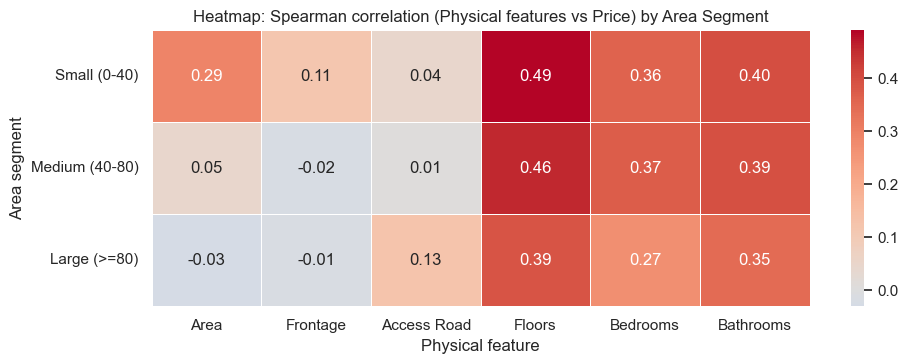

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_csv("VN_House_price_Clean2.csv")

# phân khúc Area của bạn (0–40, 40–80, >=80)
df["Segment"] = pd.cut(df["Area"], bins=[0, 40, 80, np.inf],
                       labels=["Small (0-40)", "Medium (40-80)", "Large (>=80)"],
                       include_lowest=True)

features = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]

heat = pd.DataFrame(index=df["Segment"].cat.categories, columns=features, dtype=float)

for seg in heat.index:
    tmp = df[df["Segment"] == seg]
    for f in features:
        heat.loc[seg, f] = spearmanr(tmp[f], tmp["Price"]).correlation

plt.figure(figsize=(10, 3.8))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Heatmap: Spearman correlation (Physical features vs Price) by Area Segment")
plt.xlabel("Physical feature")
plt.ylabel("Area segment")
plt.tight_layout()
plt.show()


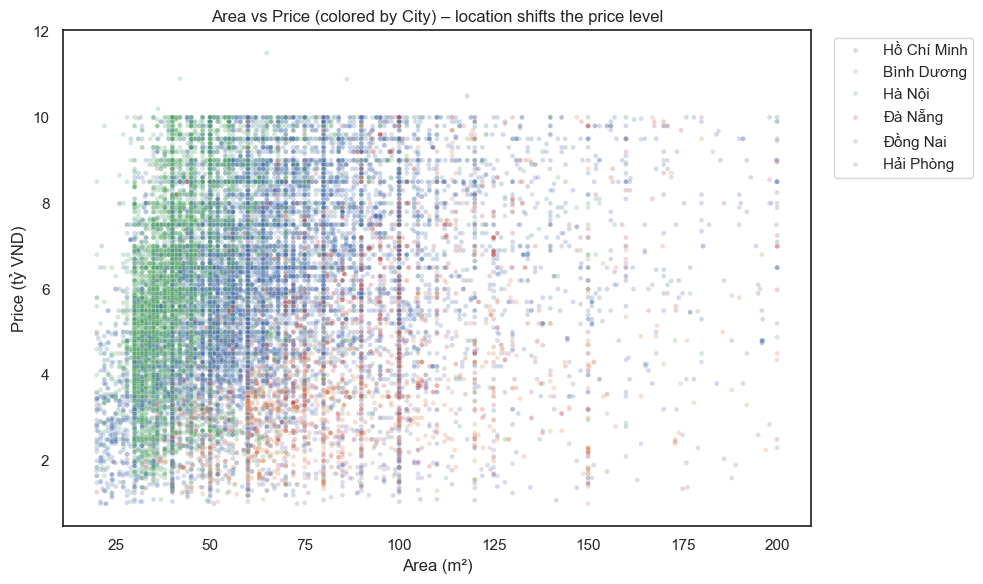

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("VN_House_price_Clean2.csv")

top_cities = df["City"].value_counts().head(6).index
tmp = df[df["City"].isin(top_cities)].copy()

plt.figure(figsize=(10,6))
sns.scatterplot(data=tmp, x="Area", y="Price", hue="City", alpha=0.25, s=12)
plt.title("Area vs Price (colored by City) – location shifts the price level")
plt.xlabel("Area (m²)")
plt.ylabel("Price (tỷ VND)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
